In [2]:
from utils import*

In [5]:
# from Leave-One-Out analysis

group1 = ['2005', '4952', '184', '325', '3016', '2003', '2002', '7523', '328', '875', '602', '2486', '212', '4011', '7574', '218', '2004', '304', '7584', '206', '4953', '1', '3997', '7577', '148', '7501', '7579', '2007', '253', '7544', '101', '297', '327', '330', '141', '109', '2492']
first10 = ['2005', '4952', '325', '2003', '2002', '602', '218', '206', '4953', '2007']

# drawing cpd map

In [8]:
# preATP 1000 runs

df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_folditer_preATP.csv', index_col=0)
df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/cpds_folditer_preATP.csv', index_col=0)
df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rns_folditer_preATP.csv', index_col=0)
df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rules_folditer_preATP.csv', index_col=0)

In [9]:
x2foMean = {}
x2foStd = {}
for x in df_folds_folditer.index:
    if x not in ['fold_independent', 'spontaneous']:
        x2foMean[x] = np.mean(df_folds_folditer.loc[x])
        x2foStd[x] = np.std(df_folds_folditer.loc[x])

print(len(x2foMean))
print(len(x2foStd))

396
396


In [128]:
all_rns = list(df_rns_folditer.index)
all_cpds = list(df_cpds_folditer.index)

# make empty dataframe with cpds*cpds
df = pd.DataFrame(0, columns=all_cpds, index=all_cpds)
for rn in all_rns:
    reac = rn2reac[rn]
    prod = rn2prod[rn]
    # fwd
    for r in reac:
        for p in prod:
            try:
                df.at[r, p] = df.at[r, p] + 1
            except:
                print(f'failed to assign {rn}: {r}, {p}')
    # rev
    for r in prod:
        for p in reac:
            try:
                df.at[r, p] = df.at[r, p] + 1
            except:
                print(f'failed to assign {rn}: {r}, {p}')

failed to assign R12455: C00001, C22173
failed to assign R12455: C00032, C22173
failed to assign R12455: C00011, C22173
failed to assign R12455: C22173, C00001
failed to assign R12455: C22173, C00032
failed to assign R12455: C22173, C00011
failed to assign R09507_v1: C01335, C01371
failed to assign R09507_v1: C00001, C01371
failed to assign R09507_v1: Z00025, C01371
failed to assign R09507_v1: Z00010, C01371
failed to assign R09507_v1: C01371, C01335
failed to assign R09507_v1: C01371, C00001
failed to assign R09507_v1: C01371, Z00025
failed to assign R09507_v1: C01371, Z00010
failed to assign MeCobamineCofactor_Synthesis: C22450, factor
failed to assign MeCobamineCofactor_Synthesis: C06021, factor
failed to assign MeCobamineCofactor_Synthesis: factor, C22450
failed to assign MeCobamineCofactor_Synthesis: factor, C06021
failed to assign R02289_v1: C00440, factor
failed to assign R02289_v1: C06021, factor
failed to assign R02289_v1: C00080, factor
failed to assign R02289_v1: Z00055, fac

## convert to truth table

In [129]:
dict(df.sum())['C00003'], dict(df.sum())['C00004']

(3041, 2402)

In [130]:
truth_df = df.map(lambda x: 1 if x > 1 else 0)

In [131]:
dict(truth_df.sum())['C00003'], dict(truth_df.sum())['C00004']

(167, 164)

In [133]:
ignore_columns = []
for k,v in dict(truth_df.sum()).items():
    if v > 100:
        print(k, cpd2name[k], v)
        ignore_columns.append(k)

Z00069 Divalent Metal (M2) 105
Z00002 4Fe4S 153
C00080 H+ 438
C00013 Diphosphate 125
Z00015 Iron 230
Z00035 PLP 210
Z00029 Mg 412
Z00030 Mn 297
C00002 ATP 134
Z00055 Calcium 138
C00008 ADP 129
C00011 CO2 179
Z00063 Generic FeS 136
C00014 Ammonia 129
C00001 H2O 664
C00009 Orthophosphate 204
Z00054 Zinc 243
Z00032 NAD/NADP 170
C00005 NADPH 149
C00003 NAD+ 167
C00006 NADP+ 161
C00004 NADH 164
C00010 CoA 123
Z00025 Heme 144
Z00013 FAD 308
Z00014 FMN 119
Z00019 Flavoprotein 207
C00007 Oxygen 217


In [35]:
cpd2foMean = {}
for x in df_cpds_folditer.index:
    cpd2foMean[x] = np.mean(df_cpds_folditer.loc[x])
cpd2foMean

{'C00133': 0.0,
 'C01182': 0.0,
 'C06377': 0.0,
 'C00957': 0.0,
 'C00542': 0.0,
 'C00158': 0.0,
 'C00033': 0.0,
 'C07836': 0.0,
 'C22029': 0.0,
 'C05519': 0.0,
 'C00979': 0.0,
 'C06201': 0.0,
 'C21336': 0.0,
 'C00217': 0.0,
 'Z00069': 0.0,
 'C05840': 0.0,
 'C19781': 0.0,
 'C00329': 0.0,
 'C00222': 0.0,
 'C07272': 0.0,
 'C00721': 0.0,
 'C00447': 0.0,
 'C02512': 0.0,
 'C00334': 0.0,
 'C00238': 0.0,
 'C21282': 0.0,
 'C21611': 0.0,
 'Z00060': 0.0,
 'C01097': 0.0,
 'C01384': 0.0,
 'C06376': 0.0,
 'C05931': 0.0,
 'C01335': 0.0,
 'C00279': 0.0,
 'C00155': 0.0,
 'C01112': 0.0,
 'C03961': 0.0,
 'C04052': 0.0,
 'C06441': 0.0,
 'C01732': 0.0,
 'C02962': 0.0,
 'C01728': 0.0,
 'C00256': 0.0,
 'C00689': 0.0,
 'C15556': 0.0,
 'C16849': 0.0,
 'C05669': 0.0,
 'C00671': 0.0,
 'C00497': 0.0,
 'C00975': 0.0,
 'C04478': 0.0,
 'C18096': 0.0,
 'C00405': 0.0,
 'C20888': 0.0,
 'C12115': 0.0,
 'C02999': 0.0,
 'C02048': 0.0,
 'C00109': 0.0,
 'C20485': 0.0,
 'C06033': 0.0,
 'C03661': 0.0,
 'C03794': 0.0,
 'C03618

In [ ]:
import networkx as nx

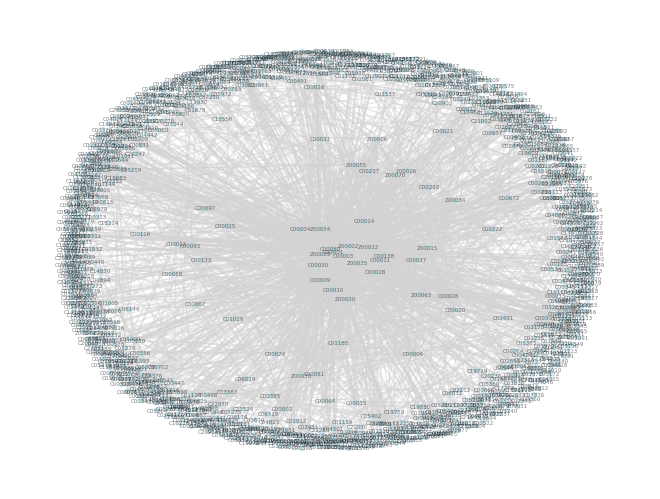

In [51]:
# Create an empty graph
G = nx.Graph()

# Add nodes (column names)
columns_0 = truth_df.columns
columns = [c for c in columns_0 if cpd2foMean[c] < 50]  # filter based on timing of discovery
# columns = [c for c in columns_0 if cpd2foMean[c] < 50 and c not in ignore_columns]  # filter based on timing of discovery & ignore_columns
G.add_nodes_from(columns)

# Add edges based on the upper triangular part of the symmetric DataFrame
for i, c1 in enumerate(columns):
    for j, c2 in enumerate(columns):
        if i < j and df.at[c1, c2] == 1:  # Only check the upper triangle
            G.add_edge(c1, c2)

# Draw the network
pos = nx.spring_layout(G, k=1.0) 
nx.draw(G, pos, with_labels=True, font_size=4 ,node_color="lightblue", node_size=10, edge_color="lightgray", alpha=0.5)
# nx.draw(G, pos, with_labels=False, node_color="lightblue", node_size=10, edge_color="lightgray", alpha=0.5)

# Display the network
plt.show()

## draw one module

In [52]:
m = []
for rns in module2rns.values():
    m.extend(rns)
print(len(set(m)))

# 2110 reactions belong to 1+ modules

2110


In [62]:
def get_all_ver(dict, rn_id):
    # Find all rns that start with the given rn_id
    matching_keys = [key for key in dict.keys() if key.startswith(rn_id)]
    return matching_keys

In [73]:
module2name

{'M00001': 'Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate',
 'M00002': 'Glycolysis, core module involving three-carbon compounds',
 'M00003': 'Gluconeogenesis, oxaloacetate => fructose-6P',
 'M00004': 'Pentose phosphate pathway (Pentose phosphate cycle)',
 'M00005': 'PRPP biosynthesis, ribose 5P => PRPP',
 'M00006': 'Pentose phosphate pathway, oxidative phase, glucose 6P => ribulose 5P',
 'M00007': 'Pentose phosphate pathway, non-oxidative phase, fructose 6P => ribose 5P',
 'M00008': 'Entner-Doudoroff pathway, glucose-6P => glyceraldehyde-3P + pyruvate',
 'M00009': 'Citrate cycle (TCA cycle, Krebs cycle)',
 'M00010': 'Citrate cycle, first carbon oxidation, oxaloacetate => 2-oxoglutarate',
 'M00011': 'Citrate cycle, second carbon oxidation, 2-oxoglutarate => oxaloacetate',
 'M00012': 'Glyoxylate cycle',
 'M00013': 'Malonate semialdehyde pathway, propanoyl-CoA => acetyl-CoA',
 'M00014': 'Glucuronate pathway (uronate pathway)',
 'M00015': 'Proline biosynthesis, glutamate => pr

In [138]:
rn2eqn['R01082_v1']

'C00122 + C00001 + Z00002 => C00149 + Z00002'

In [141]:
c_set = set()
for rn in module2rns['M00009']:
    keys = get_all_ver(rn2cpds, rn)
    for key in keys:
        for c in rn2cpds[key]:
            c_set.add(c)

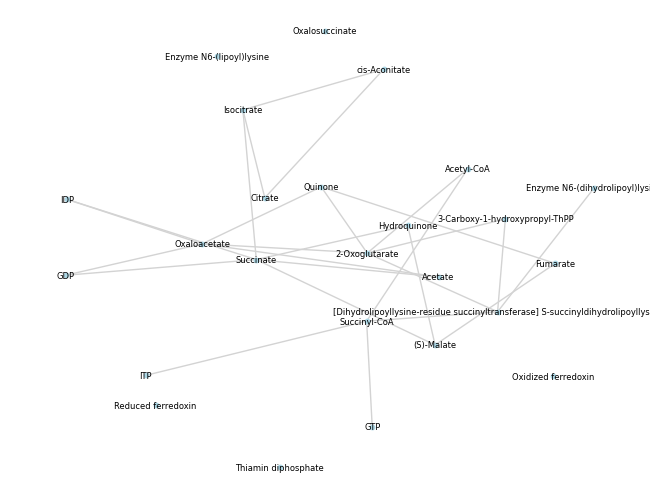

In [143]:
##### Create an empty graph
G = nx.Graph()

# Add nodes (column names)
columns_0 = truth_df.columns
columns = [c for c in columns_0 if c in c_set and c not in ignore_columns and c.startswith('C')]  # filter based on module; remove Z cofactors
G.add_nodes_from(columns)

# Add edges based on the upper triangular part of the symmetric DataFrame
for i, c1 in enumerate(columns):
    for j, c2 in enumerate(columns):
        if i < j and df.at[c1, c2] == 1:  # Only check the upper triangle
            G.add_edge(c1, c2)

# Draw the network
pos = nx.spring_layout(G, k=1.0) 
new_labels = {node: cpd2name.get(node, node) for node in G.nodes()}  # Create a list of labels based on the label_dict
nx.draw(G, pos, with_labels=True, labels=new_labels, font_size=6, node_color="lightblue", 
        node_size=10, edge_color="lightgray")

# Display the network
plt.show()

In [ ]:
# somewhat successful?

# annotating KEGG maps

In [ ]:
# rn = 'R00341'
# for rule in rn2rules[rn]:
#     print(rule)
#     for x in rule:
#         print(x, round(x2foMean[x], 2), round(x2ds[x], 2), round(x2dsEuk[x], 2), x2class[x], x in group1, x2name.get(x, 'no name'), x2arc[x])

- use KEGGscape to download KEGG maps into Cytoscape:
https://github.com/idekerlab/KEGGscape
- use xml.etree.ElementTree to automate annotation of rules

In [22]:
# func to get relevant rule information
def getRules(reaction_name):
    rule_annotations = []  # list of list
    
    # skip rns with no fold annotation
    if rn2rules.get(reaction_name, 0) == 0:
        return 0
    
    for rule in rn2rules[reaction_name]:
        rule_a = []
        for x in rule:
            x_a = []
            # append 3 info for each x
            if x in group1:
                x_a.append(f"{x}, {round(x2foMean[x], 2)}, {round(x2ds[x], 2)}, {round(x2dsEuk[x], 2)}, *group1*, {set(rule)}")
            elif x in x2foMean.keys():
                x_a.append(f"{x}, {round(x2foMean[x], 2)}, {round(x2ds[x], 2)}, {round(x2dsEuk[x], 2)}, {set(rule)}")
            else:  # ghost fold
                x_a.append(f"{x}, {set(rule)}, ghost fold")
                print(x, set(rule), 'ghost fold')
            x_a.append(x2class[x])

            # append x_a to rule_a
            rule_a.append(x_a)
        # append rule
        rule_annotations.append(rule_a)

    return rule_annotations

In [52]:
set(x2class.values())

{'a+b', 'a/b', 'alpha', 'beta', 'mixed', 'other'}

In [45]:
rn2rules['R00014']

{frozenset({'2003', '304', '7574'}),
 frozenset({'7522', '7574'}),
 frozenset({'2003', '7574'})}

In [84]:
r = getRules('R00014')
q = getRules('R13137')
r, q

([[["304, 9.0, 1.0, 1.0, *group1*, {'304', '7574', '2003'}", 'a+b'],
   ["7574, 80.01, 0.96, 1.0, *group1*, {'304', '7574', '2003'}", 'a/b'],
   ["2003, 5.0, 1.0, 1.0, *group1*, {'304', '7574', '2003'}", 'a/b']],
  [["7574, 80.01, 0.96, 1.0, *group1*, {'7574', '7522'}", 'a/b'],
   ["7522, 81.01, 0.85, 0.99, {'7574', '7522'}", 'a/b']],
  [["7574, 80.01, 0.96, 1.0, *group1*, {'7574', '2003'}", 'a/b'],
   ["2003, 5.0, 1.0, 1.0, *group1*, {'7574', '2003'}", 'a/b']]],
 0)

In [87]:
rn2rules['R01900']

{frozenset({'2487', '7542'}), frozenset({'109', '2487', '7542'})}

In [20]:
import xml.etree.ElementTree as ET

class2color = {'a+b':'#FFDE21', 'a/b':'#00FF00', 'alpha':'#FF0000', 'beta':'#0000FF', 'mixed':'#000000', 'other':'#808080'}

# Load the XML file
tree = ET.parse('/Users/tseamuscorlett/Desktop/rn00010.xml')
root = tree.getroot()

# Define an ID counter for annotation entries
annotation_id = 1000

# Loop through all 'entry' elements that represent reactions
for entry in root.findall(".//entry[@type='reaction']"):
    # Extract information from the reaction entry
    reaction_name = entry.get('name')
    graphics = entry.find('graphics')
    x = int(graphics.get('x'))
    y = int(graphics.get('y'))

    # get rules info
    rules = getRules(reaction_name[3:9])

    if rules != 0:
        for rule in rules:        
            for fold in rule:
                anno = fold[0]
                clas = fold[1]
                # Create entry for fold
                annotation_entry = ET.Element('entry', {
                    'id': str(annotation_id),
                    'name': f'annotation: {reaction_name}',  
                    'type': 'other'
                })
                annotation_graphics = ET.SubElement(annotation_entry, 'graphics', {
                    'name': f'{anno}',  # change this into rules etc.
                    'fgcolor': f'{class2color[clas]}',
                    'bgcolor': '#FFFFFF',
                    'type': 'rectangle',
                    'x': str(x+(20)),  #  adjust if necessary
                    'y': str(y+(10)),  #  adjust if necessary
                })
                # Add the annotation entry to the root
                root.append(annotation_entry)
                # Increment the annotation ID for the next entry
                annotation_id += 1
    else:  # not in rn2rules
        

# Write the modified XML back to a file
tree.write('/Users/tseamuscorlett/Desktop/annotated_rn00010.xml')


3227 {'3227', '306'} ghost fold
3227 {'325', '3227', '306'} ghost fold
7532 {'7532', '7533'} ghost fold
7533 {'7532', '7533'} ghost fold


## Get R1-7 annotations of cpds from that paper?

## Pathway onion model based on fold order (difficult for core metabolism...?)